# Noise Correlation Analysis – Refactored

## Overview
This notebook performs **noise correlation analysis** on larval zebrafish whole-brain calcium imaging data (7 dpf).

**Noise correlations** quantify shared trial-to-trial variability between neurons **after removing stimulus-evoked responses**.  
They are commonly interpreted as indicators of functional coupling, shared inputs, or coordinated network dynamics.

This analysis focuses on **area-pair level statistics**, rather than individual neuron-pair significance.

---

## Key Features
- **Flexible neuron group comparisons** — within-group or between-group
- **Stimulus and behaviour filtering**
- **Matched random baselines** — null expectations generated by sampling OTHER neurons
- **Area-level statistics** — mean, 95th, and 5th percentile correlations
- **Cross-fish aggregation** — empirical p-values, Fisher combination, FDR correction
- **Optional figure saving** — filenames automatically reflect analysis parameters

---

## Statistical Approach
1. Residuals computed by subtracting mean response per neuron per stimulus
2. Pairwise Pearson correlations between residual activity across brain areas
3. Area-pair summaries: Fisher-z mean, 95th/5th percentile, pair counts
4. Null distributions via matched random resampling from OTHER neurons
5. Empirical p-values, Fisher combination across fish, BH-FDR correction

---


## 1. Imports and Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
import os
import json

from pathlib import Path
from skimage import io
from tqdm import tqdm
from itertools import combinations, product
from ast import literal_eval

from scipy.stats import mannwhitneyu, ks_2samp, combine_pvalues, wilcoxon
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
np.random.seed(42)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Configuration and Parameters

**Modify these parameters to customise your analysis.**

In [65]:
# ============================================================================
# FILE PATHS
# ============================================================================
DATA_DIR = Path('/Volumes/LaCie/larval_HuC/imaging')

FISH_DATA_PATH         = DATA_DIR / '7dpf_wb_population_early_response_vector_50%.h5'
RESPONSE_TAG           = 'early'
# GROUP1_PATH            = DATA_DIR / '7dpf_positive_correlations_25s_no_HCl_1000_corrected.csv'
GROUP1_PATH            = '/Volumes/LaCie/larval_HuC/imaging/regression_results/7dpf_fex_1_regressor_specific_correlations_25s_1000_corrected.csv'
GROUP2_PATH            = DATA_DIR / '7dpf_new_asymm_bout_all_correlations_1000_corrected.csv'
BHV_CLASSIFICATION_PATH = DATA_DIR / 'bhv_modulation/7dpf_fb_trial_bhv_classification_10percent.csv'
NMLF_MASK_PATH         = Path('/Volumes/LaCie/area_masks/area_masks_mapzebrain/nMLF.tiff')


# ============================================================================
# FISH AND BRAIN AREAS
# ============================================================================
FISH_LIST = [
    '230713_fb', '230714_fb', '230720_fb', '230727_fb', '230728_fb',
    '230810_fb', '230811_fb', '230817_fb', '230818_fb', '230919_fb'
]

# BRAIN_AREAS = ['olfactory_bulb', 'pallium', 'subpallium',
#                'preoptic', 'posterior_tuberculum', 'intermediate_hypothalamus', 'nMLF', 'tegmentum', 'nucleus_isthmi']

    
BRAIN_AREAS = ['olfactory_bulb', 'pallium', 'subpallium', 'preoptic', 'prethalamus', 'eminentia_thalami',
    'dorsal_thalamus', 'dorsal_habenula', 'ventral_habenula', 'posterior_tuberculum',
    'rostral_hypothalamus', 'intermediate_hypothalamus', 'pretectum',  'nMLF', 'tegmentum','nucleus_isthmi'
]

# ============================================================================
# STIMULUS FILTERING
# ============================================================================
NEGATIVE_STIMULI = ['ade', 'cad_2.5mm', 'qui_2.5mm']
POSITIVE_STIMULI = ['fex_1', 'kw', 'pro_2.5mm']

# Options: None (all stimuli), NEGATIVE_STIMULI, POSITIVE_STIMULI, or a custom list
STIMULUS_FILTER = None

# ============================================================================
# ANALYSIS MODE
# ============================================================================
# 'WITHIN_GROUP1'  – NEG vs NEG
# 'WITHIN_GROUP2'  – POS vs POS
# 'BETWEEN_GROUPS' – Group 1 vs Group 2
ANALYSIS_MODE = 'BETWEEN_GROUPS'

GROUP1_LABEL = 'FEX'
GROUP2_LABEL = 'L-BCN'

# ============================================================================
# BEHAVIOUR FILTERING
# ============================================================================
# Options: 'High BHV', 'Reduced BHV', 'No BHV Chng', or None
BEHAVIOR_FILTER = None

# ============================================================================
# GROUP FILTERING
# ============================================================================
GROUP1_FDR_THRESHOLD  = 0.05
GROUP1_CORR_THRESHOLD = 0.5
GROUP2_FDR_THRESHOLD  = 0.05
GROUP2_CORR_THRESHOLD = 0.3 # e.g. 0.3, or None to skip

# ============================================================================
# STATISTICAL PARAMETERS
# ============================================================================
N_RANDOM_SAMPLES    = 1000   # null resamples per fish × area pair
FDR_ALPHA           = 0.05
MIN_PAIRS_THRESHOLD = 100    # minimum neuron pairs required for a valid area pair
MIN_NEURONS_PER_GROUP = 2
PCTL_HI             = 95
PCTL_LO             = 5

# ============================================================================
# VISUALISATION PARAMETERS
# ============================================================================
DIST_COLOR = 'limegreen'  #olivedrab'   'mediumvioletred' 'goldenrod'
COLOR_G1   = 'limegreen'
COLOR_G2   = 'black'

# ==============================
# HEATMAP AXIS CONTROL
# ==============================
USE_CUSTOM_AXES = False # True → use X_AREAS / Y_AREAS
                         # False → use all BRAIN_AREAS

# Define custom subsets (only used if USE_CUSTOM_AXES = True)
Y_AREAS = [
    'olfactory_bulb',
    'pallium',
    'subpallium',
    'preoptic',
    'posterior_tuberculum',
    'intermediate_hypothalamus'
]

X_AREAS = ['posterior_tuberculum', 'nMLF', 'tegmentum', 'nucleus_isthmi']

# ============================================================================
# FIGURE SAVING
# ============================================================================
SAVE_FIGURES = True   # Set to False to skip saving
FIGURES_DIR  = Path('/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures')
FIGURE_FORMAT = 'svg'  # 'svg', 'png', 'pdf'

# ============================================================================
# DERIVED SETTINGS  (do not edit below this line)
# ============================================================================
if ANALYSIS_MODE == 'WITHIN_GROUP1':
    color_y = color_x = COLOR_G1
    compare_same_group  = True
    use_group1_for_both = True
    use_group2_for_both = False
    active_label = GROUP1_LABEL
elif ANALYSIS_MODE == 'WITHIN_GROUP2':
    color_y = color_x = COLOR_G2
    compare_same_group  = True
    use_group1_for_both = False
    use_group2_for_both = True
    active_label = GROUP2_LABEL
elif ANALYSIS_MODE == 'BETWEEN_GROUPS':
    color_y = COLOR_G1
    color_x = COLOR_G2
    compare_same_group  = False
    use_group1_for_both = False
    use_group2_for_both = False
    active_label = None
else:
    raise ValueError(f"Invalid ANALYSIS_MODE: {ANALYSIS_MODE}")

# Axis labels used in all heatmaps
if compare_same_group:
    xlabel = ylabel = active_label
else:
    xlabel = GROUP2_LABEL
    ylabel = GROUP1_LABEL

# Short label for the comparison (used in filenames and plot titles)
if compare_same_group:
    comparison_label = f'{active_label}_vs_{active_label}'
else:
    comparison_label = f'{GROUP1_LABEL}_vs_{GROUP2_LABEL}'

# Build a filename tag from key parameters
stim_tag = (
    'all_stim' if STIMULUS_FILTER is None
    else ('neg_stim' if STIMULUS_FILTER is NEGATIVE_STIMULI
          else ('pos_stim' if STIMULUS_FILTER is POSITIVE_STIMULI
                else 'custom_stim'))
)

bhv_tag  = 'all_bhv' if BEHAVIOR_FILTER is None else BEHAVIOR_FILTER.replace(' ', '_')

FILENAME_TAG = f'{comparison_label}_{RESPONSE_TAG}_{stim_tag}_{bhv_tag}_all_areas_0.5' #_all_areas



if SAVE_FIGURES:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    print(f"✓ Figures will be saved to: {FIGURES_DIR}")
    print(f"  Filename tag: {FILENAME_TAG}")
else:
    print("⚠  Figure saving is DISABLED")

print(f"\n✓ Configuration loaded")q1
print(f"  Analysis mode  : {ANALYSIS_MODE}")
print(f"  Comparison     : {comparison_label}")
print(f"  Stimulus filter: {STIMULUS_FILTER if STIMULUS_FILTER else 'All stimuli'}")
print(f"  Behaviour filter: {BEHAVIOR_FILTER if BEHAVIOR_FILTER else 'All trials'}")
print(f"  Brain areas    : {len(BRAIN_AREAS)}")
print(f"  Fish           : {len(FISH_LIST)}")

✓ Figures will be saved to: /Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures
  Filename tag: FEX_vs_L-BCN_early_all_stim_all_bhv_all_areas_0.5

✓ Configuration loaded
  Analysis mode  : BETWEEN_GROUPS
  Comparison     : FEX_vs_L-BCN
  Stimulus filter: All stimuli
  Behaviour filter: All trials
  Brain areas    : 16
  Fish           : 10


## 3. Area Shorthand Dictionary

In [66]:
# Load in area dictionary with name and shorthand 
with open("/Volumes/LaCie/larval_HuC/imaging/brain_map_values/area_shorthand_dict.json", "r") as f:
    AREA_SHORTHAND = json.load(f)
print(f"✓ Area dictionary loaded: {len(AREA_SHORTHAND)} areas")

✓ Area dictionary loaded: 41 areas


## 4. Utility Functions

In [67]:
# ── Figure saving helper ──────────────────────────────────────────────────────

def save_figure(fig_name: str, fmt: str = FIGURE_FORMAT) -> None:
    """Save the current figure if SAVE_FIGURES is True.

    The full filename is built as:
        {FIGURES_DIR}/{fig_name}_{FILENAME_TAG}.{fmt}

    Args:
        fig_name : Descriptive name for this figure (no extension).
        fmt      : File format string (default from FIGURE_FORMAT).
    """
    if not SAVE_FIGURES:
        return
    out_path = FIGURES_DIR / f"{fig_name}_{FILENAME_TAG}.{fmt}"
    plt.savefig(out_path, format=fmt, bbox_inches='tight')
    print(f"  ✓ Figure saved: {out_path.name}")


# ── Brain mask helpers ────────────────────────────────────────────────────────

def load_nmlf_mask(mask_path: Path):
    """Load nMLF brain area mask from a TIFF file."""
    if mask_path.exists():
        mask = io.imread(str(mask_path))
        print(f"✓ Loaded nMLF mask: shape {mask.shape}")
        return mask
    print(f"⚠️  nMLF mask not found at {mask_path}")
    return None


def is_within_3d_mask(coordinates, mask) -> bool:
    """Return True if a (z, y, x) coordinate falls inside a 3-D binary mask."""
    if mask is None:
        return False
    coordinates = np.array(coordinates, dtype=int)
    if coordinates.shape != (3,):
        return False
    z, y, x = coordinates
    depth, height, width = mask.shape
    if (0 <= z < depth) and (0 <= y < height) and (0 <= x < width):
        return mask[z, y, x] > 0
    return False


# ── Data loading ──────────────────────────────────────────────────────────────

def load_group_data(group_path: Path, nmlf_mask, fdr_threshold: float,
                    corr_threshold=None) -> pd.DataFrame:
    """Load and filter a neuron-group CSV.

    Applies nMLF mask re-labelling, FDR threshold, and an optional
    correlation threshold.
    """
    df = pd.read_csv(group_path)
    df['coords_tuple'] = df['coords'].apply(literal_eval)

    if nmlf_mask is not None:
        df['area'] = df.apply(
            lambda row: 'nMLF' if is_within_3d_mask(row['coords_tuple'], nmlf_mask)
                        else row['area'],
            axis=1
        )

    df = df[df['p_fdr'] < fdr_threshold]
    if corr_threshold is not None:
        df = df[df['correlation'] >= corr_threshold]
    return df


# ── Correlation helpers ───────────────────────────────────────────────────────

def compute_noise_correlation(mat1: np.ndarray, mat2: np.ndarray,
                               same_group: bool = False) -> np.ndarray:
    """Compute pairwise Pearson correlations between rows of mat1 and mat2.

    When same_group is True and mat1 == mat2, the diagonal (self-correlations)
    is removed.
    """
    mat1, mat2 = np.asarray(mat1, dtype=float), np.asarray(mat2, dtype=float)
    C = np.corrcoef(mat1, mat2)[:mat1.shape[0], mat1.shape[0]:]
    if same_group and C.shape[0] == C.shape[1]:
        C = C[~np.eye(C.shape[0], dtype=bool)]
    return C.ravel()


def fisher_z_mean(r_values) -> float:
    """Fisher-Z mean: transform to arctanh, average, transform back."""
    r = np.asarray(r_values, dtype=float)
    r = r[np.isfinite(r)]
    if r.size == 0:
        return np.nan
    return float(np.tanh(np.mean(np.arctanh(np.clip(r, -0.9999, 0.9999)))))


def summarize_corrs(r_values):
    """Return (Fisher-z mean, PCTL_HI percentile, PCTL_LO percentile)."""
    r = np.asarray(r_values, dtype=float)
    r = r[np.isfinite(r)]
    if r.size == 0:
        return np.nan, np.nan, np.nan
    return fisher_z_mean(r), float(np.percentile(r, PCTL_HI)), float(np.percentile(r, PCTL_LO))


# ── Empirical p-value helpers ─────────────────────────────────────────────────

def _clean_null(null_dist, obs):
    """Shared validation for empirical p-value functions."""
    null = np.asarray(null_dist, dtype=float)
    null = null[np.isfinite(null)]
    valid = null.size > 0 and np.isfinite(obs)
    return null, valid


def empirical_p_two_sided(obs: float, null_dist) -> float:
    """Two-sided empirical p-value with +1 continuity correction."""
    null, valid = _clean_null(null_dist, obs)
    if not valid:
        return np.nan
    n = null.size
    p_lo = (np.sum(null <= obs) + 1) / (n + 1)
    p_hi = (np.sum(null >= obs) + 1) / (n + 1)
    return float(min(2 * min(p_lo, p_hi), 1.0))


def empirical_p_greater(obs: float, null_dist) -> float:
    """One-sided empirical p-value: P(null >= obs)."""
    null, valid = _clean_null(null_dist, obs)
    if not valid:
        return np.nan
    return float((np.sum(null >= obs) + 1) / (null.size + 1))


def empirical_p_less(obs: float, null_dist) -> float:
    """One-sided empirical p-value: P(null <= obs)."""
    null, valid = _clean_null(null_dist, obs)
    if not valid:
        return np.nan
    return float((np.sum(null <= obs) + 1) / (null.size + 1))


# ── Significance annotation ───────────────────────────────────────────────────

def pval_to_stars(p: float) -> str:
    """Convert a p-value to star notation."""
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'


# ── Heatmap building helpers ──────────────────────────────────────────────────

def filter_by_min_pairs(df: pd.DataFrame) -> pd.DataFrame:
    """Keep only area pairs whose mean neuron-pair count >= MIN_PAIRS_THRESHOLD."""
    mean_counts = (
        df.groupby(['area1', 'area2'])['n_pairs_real']
          .mean()
          .reset_index(name='mean_n_pairs')
    )
    valid = mean_counts[mean_counts['mean_n_pairs'] >= MIN_PAIRS_THRESHOLD]
    return df.merge(valid[['area1', 'area2']], on=['area1', 'area2'], how='inner')


def build_heatmap_matrix(df: pd.DataFrame, value_col: str, agg_fn=None) -> pd.DataFrame:
    """
    Pivot a summary_df column into a matrix.

    - Default aggregation: fisher_z_mean (good for correlations)
      Use agg_fn='mean' for non-correlation values (pair counts, deltas, etc.)

    - Axis control is driven by global parameters:
        USE_CUSTOM_AXES, X_AREAS, Y_AREAS
      Reindexing is done on FULL area names; shorthand is applied after.
    """
    agg_fn = agg_fn or fisher_z_mean

    # Choose axes from parameters
    if USE_CUSTOM_AXES:
        y_areas = Y_AREAS
        x_areas = X_AREAS
    else:
        y_areas = BRAIN_AREAS
        x_areas = BRAIN_AREAS

    # Build matrix on FULL names
    mat = (
        df.groupby(['area1', 'area2'])[value_col]
          .apply(agg_fn)
          .reset_index()
          .pivot(index='area1', columns='area2', values=value_col)
          .reindex(index=y_areas, columns=x_areas)
    )

    # Rename to shorthand for plotting
    mat = mat.rename(index=AREA_SHORTHAND, columns=AREA_SHORTHAND)

    # Symmetrize only if within-group AND square
    if compare_same_group and (mat.shape[0] == mat.shape[1]):
        upper = np.triu(mat.values)
        mat.values[:, :] = upper + upper.T - np.diag(np.diag(upper))

    return mat


def fisher_combine_pvalues(df: pd.DataFrame, p_col: str) -> pd.DataFrame:
    """Fisher-combine per-fish p-values for each area pair, then apply BH-FDR.

    Returns a DataFrame with columns: area1, area2, n_fish, p_fisher, p_fdr, sig.
    """
    rows = []
    for (a1, a2), g in df.groupby(['area1', 'area2'], sort=False):
        pvals = g[p_col].dropna().values
        p_fish = float(combine_pvalues(pvals, method='fisher')[1]) if len(pvals) else np.nan
        rows.append({'area1': a1, 'area2': a2,
                     'n_fish': int(g['fish_id'].nunique()),
                     'p_fisher': p_fish})

    out = pd.DataFrame(rows)
    out['p_fdr'] = np.nan
    m = out['p_fisher'].notna()
    if m.sum() > 0:
        _, q, _, _ = multipletests(out.loc[m, 'p_fisher'], method='fdr_bh')
        out.loc[m, 'p_fdr'] = q
    out['sig'] = out['p_fdr'] < FDR_ALPHA
    return out


def build_sig_matrix(masked_matrix: pd.DataFrame,
                      per_area_p: pd.DataFrame) -> pd.DataFrame:
    """Build a boolean significance matrix aligned to masked_matrix index/columns."""
    sig = pd.DataFrame(False, index=masked_matrix.index, columns=masked_matrix.columns)
    tmp = per_area_p.copy()
    tmp['a1s'] = tmp['area1'].map(AREA_SHORTHAND)
    tmp['a2s'] = tmp['area2'].map(AREA_SHORTHAND)
    for _, row in tmp.iterrows():
        if bool(row.get('sig', False)) and pd.notna(row['a1s']) and pd.notna(row['a2s']):
            sig.loc[row['a1s'], row['a2s']] = True
    if compare_same_group:
        sig = sig | sig.T
    return sig


def add_significance_stars(ax, masked_matrix: pd.DataFrame,
                            sig_matrix: pd.DataFrame) -> None:
    """Overlay significance stars on a seaborn heatmap axes object."""
    for yi, y in enumerate(masked_matrix.index):
        for xi, x in enumerate(masked_matrix.columns):
            if pd.notna(masked_matrix.loc[y, x]) and bool(sig_matrix.loc[y, x]):
                ax.text(xi + 0.5, yi + 0.5, '*',
                        ha='center', va='center_baseline',
                        fontsize=12, fontweight='bold', color='black')


def style_heatmap(ax, cbar_label: str) -> None:
    """Apply shared styling to a seaborn heatmap."""
    ax.set_facecolor('grey')
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=26)
    cbar.set_label(cbar_label, fontsize=26)
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_xlabel(xlabel, color=color_x, fontsize=20) #26 #20
    ax.set_ylabel(ylabel, color=color_y, fontsize=20) #26 #20
    plt.xticks(rotation=90, fontsize=11) #26  #11 
    plt.yticks(rotation=0,  fontsize=11) #26  #11 


print("✓ Utility functions loaded")

✓ Utility functions loaded


## 5. Load Data

In [68]:
print("Loading data files...")
print("=" * 80)

nMLF_mask = load_nmlf_mask(NMLF_MASK_PATH)

print(f"\nLoading Group 1 ({GROUP1_LABEL})...")
group1_df = load_group_data(GROUP1_PATH, nMLF_mask, GROUP1_FDR_THRESHOLD, GROUP1_CORR_THRESHOLD)
print(f"  ✓ Loaded {len(group1_df)} neurons")
print(f"  Areas: {group1_df['area'].value_counts().to_dict()}")

print(f"\nLoading Group 2 ({GROUP2_LABEL})...")
group2_df = load_group_data(GROUP2_PATH, nMLF_mask, GROUP2_FDR_THRESHOLD, GROUP2_CORR_THRESHOLD)
print(f"  ✓ Loaded {len(group2_df)} neurons")
print(f"  Areas: {group2_df['area'].value_counts().to_dict()}")

bhv_summary = None
if BEHAVIOR_FILTER is not None:
    if BHV_CLASSIFICATION_PATH.exists():
        bhv_summary = pd.read_csv(BHV_CLASSIFICATION_PATH)
        bhv_summary['trial_number'] = bhv_summary['trial_number'].astype(int)
        print(f"\n✓ Loaded behaviour classification: {len(bhv_summary)} trials")
    else:
        print(f"\n⚠️  Behaviour filter requested but file not found at {BHV_CLASSIFICATION_PATH}")
        print("   Proceeding without behaviour filtering")
        BEHAVIOR_FILTER = None

print("\n" + "=" * 80)
print("✓ All data loaded")

Loading data files...
✓ Loaded nMLF mask: shape (359, 974, 597)

Loading Group 1 (FEX)...
  ✓ Loaded 1167 neurons
  Areas: {'pallium': 368, 'olfactory_bulb': 275, 'olfactory_epithelium': 206, 'subpallium': 142, 'not_assigned': 75, 'ventral_habenula': 25, 'preoptic': 21, 'dorsal_habenula': 16, 'eminentia_thalami': 15, 'dorsal_thalamus': 5, 'prethalamus': 5, 'intermediate_hypothalamus': 4, 'tori': 2, 'inferior_dorsal_med_ob': 2, 'superior_dorsal_med_ob': 2, 'nucleus_isthmi': 1, 'rostral_hypothalamus': 1, 'posterior_tuberculum': 1, 'cerebellum': 1}

Loading Group 2 (L-BCN)...
  ✓ Loaded 8326 neurons
  Areas: {'inferior_dorsal_med_ob': 1897, 'nucleus_isthmi': 734, 'superior_dorsal_med_ob': 707, 'tegmentum': 610, 'intermediate_dorsal_med_ob': 536, 'intermediate_ventral_med_ob': 535, 'not_assigned': 357, 'posterior_tuberculum': 312, 'facial_mn': 253, 'dorsal_thalamus': 224, 'pretectum': 221, 'nMLF': 200, 'cerebellum': 197, 'subpallium': 191, 'superior_ventral_med_ob': 187, 'pallium': 168, 'i

## 6. Main Noise Correlation Analysis

Core loop: for each fish × area pair, compute real and null summary statistics,
then derive empirical p-values.

In [69]:
print("\n" + "=" * 80)
print("STARTING NOISE CORRELATION ANALYSIS")
print("=" * 80)
print(f"Mode       : {ANALYSIS_MODE}  ({comparison_label})")
print(f"Null draws : {N_RANDOM_SAMPLES}")
print(f"Min neurons: {MIN_NEURONS_PER_GROUP}")
print("=" * 80 + "\n")

# Storage for raw pairwise correlations (real and one descriptive random draw)
area_pair_corr_values  = {}   # (area1, area2) -> {fish: list[float]}
random_pair_corr_values = {}  # (area1, area2) -> {fish: list[float]}

# Main output: one row per fish × area pair
area_pair_summary_records = []

# Generate area pairs
area_pairs = (
    list(combinations(BRAIN_AREAS, 2)) + [(a, a) for a in BRAIN_AREAS]
    if compare_same_group
    else list(product(BRAIN_AREAS, BRAIN_AREAS))
)
print(f"Analysing {len(area_pairs)} area pairs across {len(FISH_LIST)} fish\n")


def _sample_null(pool: pd.DataFrame, n: int, seed: int,
                 drop_cols=('coords', 'area', 'group')) -> np.ndarray:
    """Sample n rows from pool and return stacked residual matrix."""
    samp = pool.sample(n=n, replace=False, random_state=seed)
    return np.stack(samp.drop(columns=list(drop_cols)).values)


for fish in tqdm(FISH_LIST, desc="Processing fish"):
    print(f"\nProcessing fish: {fish}")
    try:
        # ── Load & pre-process ────────────────────────────────────────────
        fish_df = pd.read_hdf(FISH_DATA_PATH, where=f"fish_id == '{fish}'")

        if STIMULUS_FILTER is not None:
            fish_df = fish_df[fish_df['stimulus'].isin(STIMULUS_FILTER)]
            print(f"  Filtered to {len(fish_df)} rows (stimuli: {STIMULUS_FILTER})")

        # Residuals: subtract per-neuron per-stimulus mean response
        fish_df['residual'] = fish_df.groupby(['neuron_id', 'stimulus'])['resp'].transform(
            lambda x: x - x.mean()
        )

        fish_df['coords'] = fish_df['coords_serialised']
        fish_df['coords_tuple'] = fish_df['coords'].apply(literal_eval)
        if nMLF_mask is not None:
            fish_df['area'] = fish_df.apply(
                lambda row: 'nMLF' if is_within_3d_mask(row['coords_tuple'], nMLF_mask)
                            else row['area'],
                axis=1
            )

        if BEHAVIOR_FILTER is not None and bhv_summary is not None:
            fish_df['trial_number'] = fish_df['trial_number'].astype(int)
            fish_df = pd.merge(
                fish_df,
                bhv_summary[['fish_id', 'stimulus', 'trial_number', 'bhv_change']],
                on=['fish_id', 'stimulus', 'trial_number'], how='inner'
            )
            fish_df = fish_df[fish_df['bhv_change'] == BEHAVIOR_FILTER]
            print(f"  Filtered to {len(fish_df)} rows (behaviour: {BEHAVIOR_FILTER})")

        # ── Assign group labels ───────────────────────────────────────────
        g1_neurons = group1_df[group1_df['fish_id'] == fish]['neuron_id']
        g2_neurons = group2_df[group2_df['fish_id'] == fish]['neuron_id']

        fish_df['group'] = 'OTHER'
        fish_df.loc[fish_df['neuron_id'].isin(g1_neurons), 'group'] = 'G1'
        fish_df.loc[
            fish_df['neuron_id'].isin(g2_neurons) & (fish_df['group'] != 'G1'),
            'group'
        ] = 'G2'

        # ── Pivot to neuron × trial matrix ────────────────────────────────
        pivot_df = fish_df.pivot_table(
            index=['coords', 'area', 'group'],
            columns=['stimulus', 'trial_number'],
            values='residual'
        ).dropna(axis=0, how='all').reset_index()

        # ── Neuron counts ─────────────────────────────────────────────────
        if compare_same_group:
            grp = 'G1' if use_group1_for_both else 'G2'
            lbl = GROUP1_LABEL if use_group1_for_both else GROUP2_LABEL
            print(f"  Neurons: {lbl}={len(pivot_df[pivot_df['group']==grp])}, "
                  f"OTHER={len(pivot_df[pivot_df['group']=='OTHER'])}")
        else:
            print(f"  Neurons: {GROUP1_LABEL}={len(pivot_df[pivot_df['group']=='G1'])}, "
                  f"{GROUP2_LABEL}={len(pivot_df[pivot_df['group']=='G2'])}, "
                  f"OTHER={len(pivot_df[pivot_df['group']=='OTHER'])}")

        # ── Area-pair loop ────────────────────────────────────────────────
        for area1, area2 in area_pairs:

            if use_group1_for_both:
                g1 = pivot_df[(pivot_df['group'] == 'G1') & (pivot_df['area'] == area1)]
                g2 = pivot_df[(pivot_df['group'] == 'G1') & (pivot_df['area'] == area2)]
                same_group_flag = (area1 == area2)
            elif use_group2_for_both:
                g1 = pivot_df[(pivot_df['group'] == 'G2') & (pivot_df['area'] == area1)]
                g2 = pivot_df[(pivot_df['group'] == 'G2') & (pivot_df['area'] == area2)]
                same_group_flag = (area1 == area2)
            else:
                g1 = pivot_df[(pivot_df['group'] == 'G1') & (pivot_df['area'] == area1)]
                g2 = pivot_df[(pivot_df['group'] == 'G2') & (pivot_df['area'] == area2)]
                same_group_flag = False

            r1_pool = pivot_df[(pivot_df['group'] == 'OTHER') & (pivot_df['area'] == area1)]
            r2_pool = pivot_df[(pivot_df['group'] == 'OTHER') & (pivot_df['area'] == area2)]

            n1, n2, nr1, nr2 = len(g1), len(g2), len(r1_pool), len(r2_pool)

            if n1 < MIN_NEURONS_PER_GROUP or n2 < MIN_NEURONS_PER_GROUP \
               or nr1 < n1 or nr2 < n2:
                continue

            # Real correlations
            drop_cols = ['coords', 'area', 'group']
            mat1 = np.stack(g1.drop(columns=drop_cols).values)
            mat2 = np.stack(g2.drop(columns=drop_cols).values)
            flat_corr_real = compute_noise_correlation(
                mat1, mat1 if same_group_flag else mat2,
                same_group=same_group_flag
            )
            real_mean_r, real_r95, real_r5 = summarize_corrs(flat_corr_real)
            area_pair_corr_values.setdefault((area1, area2), {})[fish] = flat_corr_real.tolist()

            # One descriptive random draw (for distribution plots)
            if same_group_flag:
                mat_r = _sample_null(r1_pool, n1, seed=42)
                corr_r_desc = compute_noise_correlation(mat_r, mat_r, same_group=True)
            else:
                mat_r1 = _sample_null(r1_pool, n1, seed=42)
                mat_r2 = _sample_null(r2_pool, n2, seed=42042)
                corr_r_desc = compute_noise_correlation(mat_r1, mat_r2, same_group=False)
            random_pair_corr_values.setdefault((area1, area2), {})[fish] = corr_r_desc.tolist()

            # Null distributions via repeated resampling
            null_mean = np.empty(N_RANDOM_SAMPLES)
            null_r95  = np.empty(N_RANDOM_SAMPLES)
            null_r5   = np.empty(N_RANDOM_SAMPLES)

            for s in range(N_RANDOM_SAMPLES):
                if same_group_flag:
                    mat_r = _sample_null(r1_pool, n1, seed=s)
                    corr_null = compute_noise_correlation(mat_r, mat_r, same_group=True)
                else:
                    mat_r1 = _sample_null(r1_pool, n1, seed=s)
                    mat_r2 = _sample_null(r2_pool, n2, seed=s + 10_000)
                    corr_null = compute_noise_correlation(mat_r1, mat_r2, same_group=False)
                null_mean[s], null_r95[s], null_r5[s] = summarize_corrs(corr_null)

            area_pair_summary_records.append({
                'fish_id': fish, 'area1': area1, 'area2': area2,
                'n1': int(n1), 'n2': int(n2),
                'n_pairs_real': int(len(flat_corr_real)),
                'real_mean_r': real_mean_r, 'real_r95': real_r95, 'real_r5': real_r5,
                'p_mean': empirical_p_two_sided(real_mean_r, null_mean),
                'p_r95':  empirical_p_greater(real_r95, null_r95),
                'p_r5':   empirical_p_less(real_r5, null_r5),
                'rand_mean_mean': float(np.nanmean(null_mean)),
                'rand_mean_r95':  float(np.nanmean(null_r95)),
                'rand_mean_r5':   float(np.nanmean(null_r5)),
            })

    except Exception as e:
        print(f"  ⚠️  Error processing {fish}: {e}")
        continue

print("\n" + "=" * 80)
print("✓ Analysis complete")
print(f"  Fish×area-pair rows : {len(area_pair_summary_records)}")
print(f"  Area pairs with data: {len(area_pair_corr_values)}")
print("=" * 80)

summary_df = pd.DataFrame(area_pair_summary_records)


STARTING NOISE CORRELATION ANALYSIS
Mode       : BETWEEN_GROUPS  (FEX_vs_L-BCN)
Null draws : 1000
Min neurons: 2

Analysing 256 area pairs across 10 fish



Processing fish:   0%|                                   | 0/10 [00:00<?, ?it/s]


Processing fish: 230713_fb
  Neurons: FEX=172, L-BCN=159, OTHER=6366


Processing fish:  10%|██▌                       | 1/10 [02:16<20:26, 136.25s/it]


Processing fish: 230714_fb
  Neurons: FEX=0, L-BCN=42, OTHER=7612


...


Processing fish: 230818_fb
  Neurons: FEX=109, L-BCN=355, OTHER=7886


Processing fish:  90%|███████████████████████▍  | 9/10 [16:42<02:04, 124.21s/it]


Processing fish: 230919_fb
  Neurons: FEX=0, L-BCN=790, OTHER=10845


Processing fish: 100%|█████████████████████████| 10/10 [17:24<00:00, 104.43s/it]


✓ Analysis complete
  Fish×area-pair rows : 465
  Area pairs with data: 151


### 7. Quick Data Checks

In [70]:
area = 'olfactory_bulb'
ob = summary_df[(summary_df['area1'] == area) & (summary_df['area2'] == area)]
print(ob[['fish_id', 'n_pairs_real']].sort_values('n_pairs_real'))
print(f"Mean pairs : {ob['n_pairs_real'].mean():.1f}")
print(f"Fish ≥100  : {(ob['n_pairs_real'] >= 100).sum()} / {ob['fish_id'].nunique()}")

print("\nFish in summary_df:", summary_df['fish_id'].unique())
print("Fish missing:", set(FISH_LIST) - set(summary_df['fish_id'].unique()))

       fish_id  n_pairs_real
339  230818_fb            60
0    230713_fb           152
176  230727_fb           205
216  230728_fb           680
Mean pairs : 274.2
Fish ≥100  : 3 / 4

Fish in summary_df: ['230713_fb' '230720_fb' '230727_fb' '230728_fb' '230811_fb' '230817_fb'
 '230818_fb']
Fish missing: {'230810_fb', '230919_fb', '230714_fb'}


## Inter-area vs Intra-area Distributions 

In [92]:
intra_corrs = []
inter_corrs = []

# Loop through stored raw correlation values
for (area1, area2), fish_dict in area_pair_corr_values.items():
    
    # only keep VEN↔VEN area pairs
    if area1 not in BRAIN_AREAS or area2 not in BRAIN_AREAS:
        continue
    
    for fish, corr_values in fish_dict.items():
        if corr_values is None or len(corr_values) == 0:
            continue
        
        if area1 == area2:
            intra_corrs.extend(corr_values)
        else:
            inter_corrs.extend(corr_values)

print(f'intra pairs: {len(intra_corrs)}')
print(f'inter pairs: {len(inter_corrs)}')

intra pairs: 1667
inter pairs: 17906


In [24]:
# ---------- helper ----------
def pval_to_stars(p):
    if p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 5e-2:
        return "*"
    else:
        return "ns"

# ---------- use existing arrays only ----------
intra_vals = np.array(intra_corrs, dtype=float)
inter_vals = np.array(inter_corrs, dtype=float)
fish_intra = np.array(fish_intra_means, dtype=float)
fish_inter = np.array(fish_inter_means, dtype=float)
ks_D = np.array(ks_D_values, dtype=float)

# remove NaNs
intra_vals = intra_vals[~np.isnan(intra_vals)]
inter_vals = inter_vals[~np.isnan(inter_vals)]
fish_intra = fish_intra[~np.isnan(fish_intra)]
fish_inter = fish_inter[~np.isnan(fish_inter)]
ks_D = ks_D[~np.isnan(ks_D)]

# ---------- sanity checks ----------
print("Using precomputed values only")
print("Fish used:", fish_used)
print("n fish:", len(fish_used))
print("fish_intra_means:", fish_intra)
print("fish_inter_means:", fish_inter)

# ---------- pooled-pair tests ----------
u_stat, u_p = mannwhitneyu(intra_vals, inter_vals, alternative='two-sided')
ks_stat, ks_p = ks_2samp(intra_vals, inter_vals)

# ---------- mixed-effects model from existing fish means ----------
lme_records = []
for fish, intra, inter in zip(fish_used, fish_intra, fish_inter):
    lme_records.append({'fish': fish, 'correlation': inter, 'condition': 'inter'})
    lme_records.append({'fish': fish, 'correlation': intra, 'condition': 'intra'})

lme_df = pd.DataFrame(lme_records)
lme_df['condition'] = pd.Categorical(lme_df['condition'], categories=['inter', 'intra'])

lme_model = smf.mixedlm("correlation ~ condition", lme_df, groups=lme_df["fish"])
lme_result = lme_model.fit()

lme_intercept = lme_result.params['Intercept']
lme_beta = lme_result.params['condition[T.intra]']
lme_p = lme_result.pvalues['condition[T.intra]']
lme_ci_low, lme_ci_high = lme_result.conf_int().loc['condition[T.intra]']

# ---------- per-fish KS D consistency ----------
ksd_w_stat, ksd_w_p = wilcoxon(ks_D)

# ---------- summary values ----------
pooled_intra_mean = np.mean(intra_vals)
pooled_inter_mean = np.mean(inter_vals)

fish_intra_mean = np.mean(fish_intra)
fish_inter_mean = np.mean(fish_inter)
fish_intra_sem = np.std(fish_intra, ddof=1) / np.sqrt(len(fish_intra))
fish_inter_sem = np.std(fish_inter, ddof=1) / np.sqrt(len(fish_inter))

ksD_mean = np.mean(ks_D)
ksD_median = np.median(ks_D)

# ---------- colors ----------
INTRA_COLOR = DIST_COLOR
INTER_COLOR = 'darkgreen'

# ---------- plot ----------
fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(
    intra_vals,
    bins=50,
    alpha=0.55,
    density=True,
    label='Intra-area',
    color=INTRA_COLOR
)

ax.hist(
    inter_vals,
    bins=50,
    histtype='step',
    linewidth=2.5,
    density=True,
    label='Inter-area',
    color=INTER_COLOR
)

ax.axvline(
    pooled_intra_mean,
    color=INTRA_COLOR,
    linestyle='--',
    linewidth=2
)

ax.axvline(
    pooled_inter_mean,
    color=INTER_COLOR,
    linestyle='--',
    linewidth=2
)

stats_text = (
    "Pooled pairs\n"
    f"Intra n = {len(intra_vals)}\n"
    f"Inter n = {len(inter_vals)}\n"
    f"MWU: p = {u_p:.2e} ({pval_to_stars(u_p)})\n"
    f"KS: D = {ks_stat:.3f}, p = {ks_p:.2e} ({pval_to_stars(ks_p)})\n"
    f"intra mean = {pooled_intra_mean:.4f}\n"
    f"inter mean = {pooled_inter_mean:.4f}\n\n"

    "Per-fish means (LME)\n"
    f"Intra = {fish_intra_mean:.3f} ± {fish_intra_sem:.3f}\n"
    f"Inter = {fish_inter_mean:.3f} ± {fish_inter_sem:.3f}\n"
    f"β(intra-inter) = {lme_beta:.3f}\n"
    f"LME: p = {lme_p:.3e} ({pval_to_stars(lme_p)})\n\n"

    "Per-fish KS D\n"
    f"mean D = {ksD_mean:.3f}\n"
    f"median D = {ksD_median:.3f}\n"
    f"Wilcoxon vs 0: p = {ksd_w_p:.3e} ({pval_to_stars(ksd_w_p)})"
)

ax.text(
    0.98, 0.98, stats_text,
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=12,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='0.7', alpha=0.95)
)

ax.set_xlabel('Noise correlation', fontsize=18)
ax.set_ylabel('Density', fontsize=18)
ax.set_title('-VEN vs -VEN noise correlations: intra-area vs inter-area', fontsize=16)

ax.legend(fontsize=13, loc='upper left', frameon=False)

ax.tick_params(axis='both', labelsize=14)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(1.5)

plt.tight_layout()
# save_figure('Intra_vs_Inter_noise_corr_distribution')
plt.show()

# ---------- printouts ----------
print("\nPooled pairs")
print(f"  intra mean = {pooled_intra_mean:.4f}")
print(f"  inter mean = {pooled_inter_mean:.4f}")
print(f"  Mann–Whitney U: U = {u_stat:.3g}, p = {u_p:.2e} {pval_to_stars(u_p)}")
print(f"  KS: D = {ks_stat:.4f}, p = {ks_p:.2e} {pval_to_stars(ks_p)}")

print("\nPer-fish means (mixed model)")
print(f"  intra mean = {fish_intra_mean:.4f} ± {fish_intra_sem:.4f}")
print(f"  inter mean = {fish_inter_mean:.4f} ± {fish_inter_sem:.4f}")
print(f"  intercept (inter) = {lme_intercept:.4f}")
print(f"  beta (intra-inter) = {lme_beta:.4f}")
print(f"  95% CI = [{lme_ci_low:.4f}, {lme_ci_high:.4f}]")
print(f"  LME p = {lme_p:.2e} {pval_to_stars(lme_p)}")

print("\nPer-fish KS D")
print(f"  mean D = {ksD_mean:.4f}")
print(f"  median D = {ksD_median:.4f}")
print(f"  Wilcoxon vs 0: W = {ksd_w_stat:.3g}, p = {ksd_w_p:.2e} {pval_to_stars(ksd_w_p)}")

print("\nMixed model summary")
print(lme_result.summary())

NameError: name 'fish_intra_means' is not defined

In [65]:
# ---------- helper ----------
def pval_to_stars(p):
    if p < 1e-4:
        return "p < 0.001"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 5e-2:
        return "*"
    else:
        return "ns"

# ---------- arrays ----------
intra_vals = np.array(intra_corrs, dtype=float)
inter_vals = np.array(inter_corrs, dtype=float)

intra_vals = intra_vals[~np.isnan(intra_vals)]
inter_vals = inter_vals[~np.isnan(inter_vals)]

fish_intra = np.array(fish_intra_means, dtype=float)
fish_inter = np.array(fish_inter_means, dtype=float)

fish_intra = fish_intra[~np.isnan(fish_intra)]
fish_inter = fish_inter[~np.isnan(fish_inter)]

ks_D = np.array(ks_D_values, dtype=float)
ks_D = ks_D[~np.isnan(ks_D)]

# ---------- pooled-pair tests ----------
u_stat, u_p = mannwhitneyu(intra_vals, inter_vals, alternative='two-sided')
ks_stat, ks_p = ks_2samp(intra_vals, inter_vals)

# ---------- per-fish tests ----------
w_stat, w_p = wilcoxon(fish_intra, fish_inter, alternative='two-sided')

# KS D values are always >= 0, so this is more a consistency check
ksd_w_stat, ksd_w_p = wilcoxon(ks_D)

# ---------- summary values ----------
pooled_intra_mean = np.mean(intra_vals)
pooled_inter_mean = np.mean(inter_vals)

fish_intra_mean = np.mean(fish_intra)
fish_inter_mean = np.mean(fish_inter)
fish_intra_sem = np.std(fish_intra, ddof=1) / np.sqrt(len(fish_intra))
fish_inter_sem = np.std(fish_inter, ddof=1) / np.sqrt(len(fish_inter))

ksD_mean = np.mean(ks_D)
ksD_median = np.median(ks_D)

# ---------- colors ----------
INTRA_COLOR = DIST_COLOR #'goldenrod'   # magenta
INTER_COLOR = 'purple' #'darkgoldenrod'

# ---------- plot ----------
fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(
    intra_vals,
    bins=50,
    alpha=0.55,
    density=True,
    label='Intra-area',
    color=INTRA_COLOR
)

ax.hist(
    inter_vals,
    bins=50,
    histtype='step',
    linewidth=2.5,
    density=True,
    label='Inter-area',
    color=INTER_COLOR
)

ax.axvline(
    pooled_intra_mean,
    color=INTRA_COLOR,
    linestyle='--',
    linewidth=2
)

ax.axvline(
    pooled_inter_mean,
    color=INTER_COLOR,
    linestyle='--',
    linewidth=2
)

# ---------- stats text ----------
stats_text = (
    "Pooled pairs\n"
    f"Intra n = {len(intra_vals)}\n"
    f"Inter n = {len(inter_vals)}\n"
    f"MWU: p = {u_p:.2e} ({pval_to_stars(u_p)})\n"
    f"KS: D = {ks_stat:.2f}, p = {ks_p:.2e} ({pval_to_stars(ks_p)})\n"
    f"  intra mean = {pooled_intra_mean:.2f}\n"
    f"  inter mean = {pooled_inter_mean:.2f}\n\n"
    
    "Per-fish means\n"
    f"Intra = {fish_intra_mean:.2f} ± {fish_intra_sem:.2f}\n"
    f"Inter = {fish_inter_mean:.2f} ± {fish_inter_sem:.2f}\n"
    f"Wilcoxon: p = {w_p:.2f} ({pval_to_stars(w_p)})\n\n"
    "Per-fish KS D\n"
    f"mean D = {ksD_mean:.2f}\n"
    f"median D = {ksD_median:.2f}\n"
    f"Wilcoxon vs 0: p = {ksd_w_p:.3e} ({pval_to_stars(ksd_w_p)})"
)

ax.text(
    0.98, 0.98, stats_text,
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=12,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='0.7', alpha=0.95)
)

# ---------- labels ----------
ax.set_xlabel('Noise correlation', fontsize=18)
ax.set_ylabel('Density', fontsize=18)
ax.set_title('+VENs vs S-BCNs noise correlations: intra-area vs inter-area', fontsize=16)

ax.legend(fontsize=13, loc='upper left', frameon=False)

ax.tick_params(axis='both', labelsize=14)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(1.5)

plt.tight_layout()
save_figure('Intra_vs_Inter_noise_corr_distribution')
plt.show()

# ---------- printouts ----------
print("Pooled pairs")
print(f"  intra mean = {pooled_intra_mean:.4f}")
print(f"  inter mean = {pooled_inter_mean:.4f}")
print(f"  Mann–Whitney U: U = {u_stat:.3g}, p = {u_p:.2e} {pval_to_stars(u_p)}")
print(f"  KS: D = {ks_stat:.4f}, p = {ks_p:.2e} {pval_to_stars(ks_p)}")

print("\nPer-fish means")
print(f"  intra mean = {fish_intra_mean:.4f} ± {fish_intra_sem:.4f}")
print(f"  inter mean = {fish_inter_mean:.4f} ± {fish_inter_sem:.4f}")
print(f"  Wilcoxon: W = {w_stat:.3g}, p = {w_p:.2e} {pval_to_stars(w_p)}")

print("\nPer-fish KS D")
print(f"  mean D = {ksD_mean:.4f}")
print(f"  median D = {ksD_median:.4f}")
print(f"  Wilcoxon vs 0: W = {ksd_w_stat:.3g}, p = {ksd_w_p:.2e} {pval_to_stars(ksd_w_p)}")

NameError: name 'fish_intra_means' is not defined

## 8. Visualisation

All figures call `save_figure(name)` at the end. To disable saving for a single
cell, temporarily set `SAVE_FIGURES = False` in the config cell above.

### 8.1 Distribution: Real vs Random

  ✓ Figure saved: noise_corr_distribution_stats_CAD_vs_L-BCN_early_all_stim_all_bhv_all_areas_0.5.svg


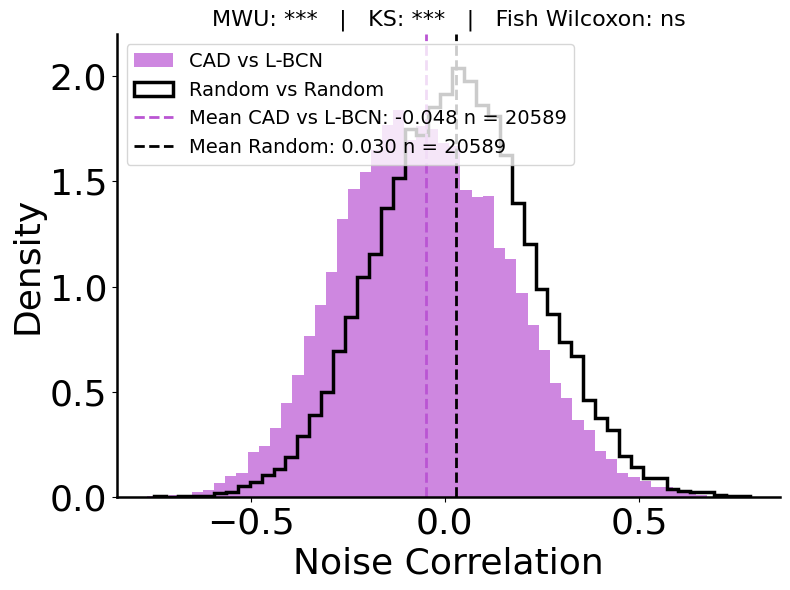


Real  : mean=-0.0482, std=0.2133
Random: mean=0.0297, std=0.2012
Mann-Whitney p=1.30e-307 ***
KS           p=5.08e-239 ***

Per-fish means (4 fish):
Fish used: ['230714_fb', '230727_fb', '230728_fb', '230817_fb']
Real per-fish mean   = -0.0054
Random per-fish mean = 0.0271
Wilcoxon p=3.75e-01 ns


In [56]:
real_vals = [v for pair in area_pair_corr_values.values()
             for vals in pair.values() for v in vals]
rand_vals = [v for pair in random_pair_corr_values.values()
             for vals in pair.values() for v in vals]

real_label = f'{active_label} vs {active_label}' if compare_same_group \
             else f'{GROUP1_LABEL} vs {GROUP2_LABEL}'

if real_vals and rand_vals:
    # pooled-pair tests
    u_stat, u_p = mannwhitneyu(real_vals, rand_vals, alternative='two-sided')
    ks_stat, ks_p = ks_2samp(real_vals, rand_vals)

    # per-fish paired means
    common_fish = sorted(
        set(f for pair in area_pair_corr_values.values() for f in pair.keys()) &
        set(f for pair in random_pair_corr_values.values() for f in pair.keys())
    )

    fish_real_means = []
    fish_rand_means = []
    fish_used = []

    for fish in common_fish:
        fish_real = []
        fish_rand = []

        for pair in area_pair_corr_values.values():
            if fish in pair:
                fish_real.extend(pair[fish])

        for pair in random_pair_corr_values.values():
            if fish in pair:
                fish_rand.extend(pair[fish])

        fish_real = np.array(fish_real, dtype=float)
        fish_rand = np.array(fish_rand, dtype=float)

        fish_real = fish_real[~np.isnan(fish_real)]
        fish_rand = fish_rand[~np.isnan(fish_rand)]

        if len(fish_real) > 0 and len(fish_rand) > 0:
            fish_real_means.append(np.mean(fish_real))
            fish_rand_means.append(np.mean(fish_rand))
            fish_used.append(fish)

    fish_real_means = np.array(fish_real_means, dtype=float)
    fish_rand_means = np.array(fish_rand_means, dtype=float)

    if len(fish_real_means) > 0:
        w_stat, w_p = wilcoxon(fish_real_means, fish_rand_means, alternative='two-sided')
    else:
        w_stat, w_p = np.nan, np.nan

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.hist(real_vals, bins=50, alpha=0.7, density=True,
            label=real_label, color=DIST_COLOR)
    ax.hist(rand_vals, bins=50, histtype='step', linewidth=2.5, density=True,
            label='Random vs Random', color='black')
    ax.axvline(np.mean(real_vals), color=DIST_COLOR, linestyle='--', linewidth=2,
               label=f'Mean {real_label}: {np.mean(real_vals):.3f} n = {len(real_vals)}')
    ax.axvline(np.mean(rand_vals), color='black', linestyle='--', linewidth=2,
               label=f'Mean Random: {np.mean(rand_vals):.3f} n = {len(rand_vals)}')

    ax.set_xlabel('Noise Correlation', fontsize=26)
    ax.set_ylabel('Density', fontsize=26)
    ax.set_title(
        f'MWU: {pval_to_stars(u_p)}   |   KS: {pval_to_stars(ks_p)}   |   Fish Wilcoxon: {pval_to_stars(w_p)}',
        fontsize=16
    )
    ax.legend(fontsize=14, loc='upper left')
    ax.set_ylim(0, 2.2)
    ax.tick_params(axis='both', labelsize=26)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_linewidth(1.8)

    plt.tight_layout()
    save_figure('noise_corr_distribution_stats')
    plt.show()

    print(f"\nReal  : mean={np.mean(real_vals):.4f}, std={np.std(real_vals):.4f}")
    print(f"Random: mean={np.mean(rand_vals):.4f}, std={np.std(rand_vals):.4f}")
    print(f"Mann-Whitney p={u_p:.2e} {pval_to_stars(u_p)}")
    print(f"KS           p={ks_p:.2e} {pval_to_stars(ks_p)}")

    print(f"\nPer-fish means ({len(fish_used)} fish):")
    print("Fish used:", fish_used)
    print(f"Real per-fish mean   = {np.mean(fish_real_means):.4f}")
    print(f"Random per-fish mean = {np.mean(fish_rand_means):.4f}")
    print(f"Wilcoxon p={w_p:.2e} {pval_to_stars(w_p)}")
else:
    print("⚠️  Not enough data for distribution plot")

### 8.2 Neuron Pair Counts Heatmap

  ✓ Figure saved: neuron_pair_counts_CAD_vs_L-BCN_early_all_stim_all_bhv_all_areas_0.5.svg


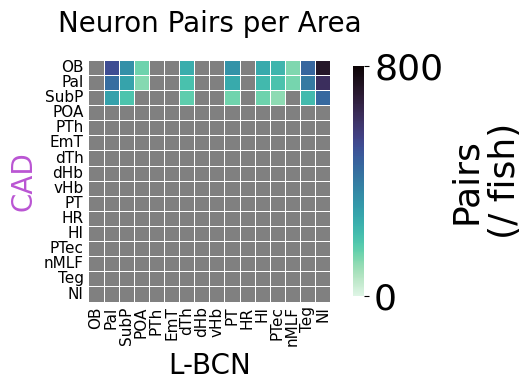

In [57]:
if summary_df is not None and len(summary_df) > 0:
    mat = build_heatmap_matrix(summary_df, 'n_pairs_real', agg_fn='mean')
    # ---------------------------------------
    # Apply axis selection logic
    # ---------------------------------------
    masked = mat.mask(mat < MIN_PAIRS_THRESHOLD)

    max_val  = np.nanmax(masked.values)
    vmax_rnd = int(np.ceil(max_val / 100.0) * 100)

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(masked, cmap='mako_r', annot=False, square=True,
                linewidths=0.5, vmin=0, vmax=vmax_rnd,
                cbar_kws={'shrink': 0.95}, ax=ax)

    style_heatmap(ax, 'Pairs\n(/ fish)')
    cbar = ax.collections[0].colorbar
    cbar.set_ticks([0, vmax_rnd])
    cbar.set_ticklabels([0, vmax_rnd])
    ax.set_title('Neuron Pairs per Area', fontsize=20, pad=20)

    plt.tight_layout()
    save_figure('neuron_pair_counts')
    plt.show()
else:
    print("⚠️  summary_df is empty")

### 8.3 Mean Correlation Heatmap (Real)

  ✓ Figure saved: mean_noise_corr_real_CAD_vs_L-BCN_early_all_stim_all_bhv_all_areas_0.5.svg


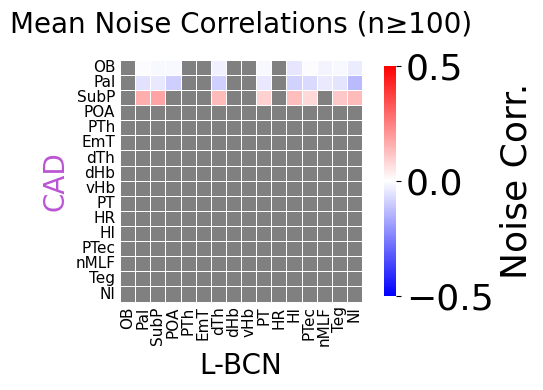

In [58]:
if summary_df is not None and len(summary_df) > 0:
    df_plot = filter_by_min_pairs(summary_df)
    mat = build_heatmap_matrix(df_plot, 'real_mean_r')
    masked = mat.mask(mat == 0)

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(masked, vmin=-0.5, vmax=0.5, cmap='bwr', annot=False,
                square=True, linewidths=0.5,
                cbar_kws={'shrink': 0.95}, ax=ax)
    style_heatmap(ax, 'Noise Corr.')
    ax.set_title(f'Mean Noise Correlations (n≥{MIN_PAIRS_THRESHOLD})', fontsize=20, pad=20)

    plt.tight_layout()
    save_figure('mean_noise_corr_real')
    plt.show()
else:
    print("⚠️  summary_df is empty")

### 8.4 Mean Correlation Heatmap (Null)

  ✓ Figure saved: mean_noise_corr_null_CAD_vs_L-BCN_early_all_stim_all_bhv_all_areas_0.5.svg


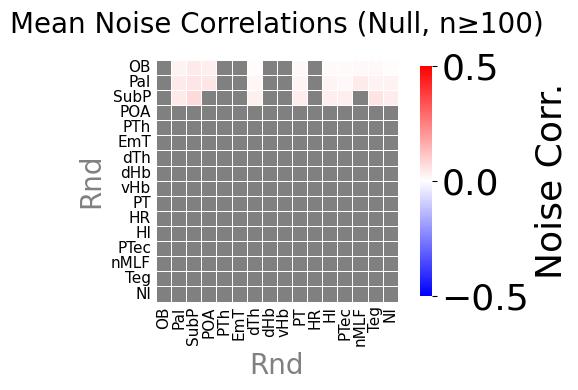

In [59]:
if summary_df is not None and len(summary_df) > 0:
    df_plot = filter_by_min_pairs(summary_df)
    mat = build_heatmap_matrix(df_plot, 'rand_mean_mean')
    masked = mat.mask(mat == 0)

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(masked, vmin=-0.5, vmax=0.5, cmap='bwr', annot=False,
                square=True, linewidths=0.5,
                cbar_kws={'shrink': 0.95}, ax=ax)
    ax.set_facecolor('grey')
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=26)
    cbar.set_label('Noise Corr.', fontsize=26)
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_xlabel('Rnd', color='gray', fontsize=20)
    ax.set_ylabel('Rnd', color='gray', fontsize=20)
    ax.set_title(f'Mean Noise Correlations (Null, n≥{MIN_PAIRS_THRESHOLD})', fontsize=20, pad=20)
    plt.xticks(rotation=90, fontsize=11)
    plt.yticks(rotation=0,  fontsize=11)

    plt.tight_layout()
    save_figure('mean_noise_corr_null')
    plt.show()
else:
    print("⚠️  summary_df is empty")

### 8.5 Δ Mean Correlation Heatmap (Real − Null) with Significance Stars

  ✓ Figure saved: delta_mean_noise_corr_CAD_vs_L-BCN_early_all_stim_all_bhv_all_areas_0.5.svg


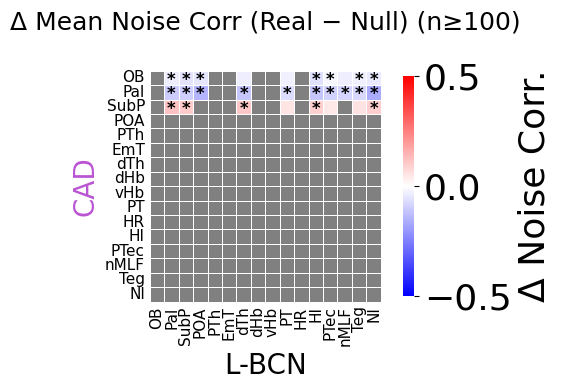

In [60]:
if summary_df is not None and len(summary_df) > 0:
    df = filter_by_min_pairs(summary_df.copy())
    df['diff_mean_r'] = df['real_mean_r'] - df['rand_mean_mean']

    if len(df) > 0:
        mat = build_heatmap_matrix(df, 'diff_mean_r', agg_fn='mean')
        masked = mat.mask(mat == 0)
        per_area_p = fisher_combine_pvalues(df, 'p_mean')
        sig_matrix = build_sig_matrix(masked, per_area_p)

        fig, ax = plt.subplots(figsize=(6, 4))
        sns.heatmap(masked, vmin=-0.5, vmax=0.5, cmap='bwr', annot=False,
                    square=True, linewidths=0.5,
                    cbar_kws={'shrink': 0.95}, ax=ax)
        style_heatmap(ax, 'Δ Noise Corr.')
        ax.set_title(f'Δ Mean Noise Corr (Real − Null) (n≥{MIN_PAIRS_THRESHOLD})',
                     fontsize=18, pad=30)
        add_significance_stars(ax, masked, sig_matrix)

        plt.tight_layout()
        save_figure('delta_mean_noise_corr')
        plt.show()
    else:
        print("⚠️  No area pairs after MIN_PAIRS_THRESHOLD filtering")
else:
    print("⚠️  summary_df is empty")

### 8.6 Δ 95th Percentile Correlation Heatmap

  ✓ Figure saved: delta_r95_noise_corr_CAD_vs_L-BCN_early_all_stim_all_bhv_all_areas_0.5.svg


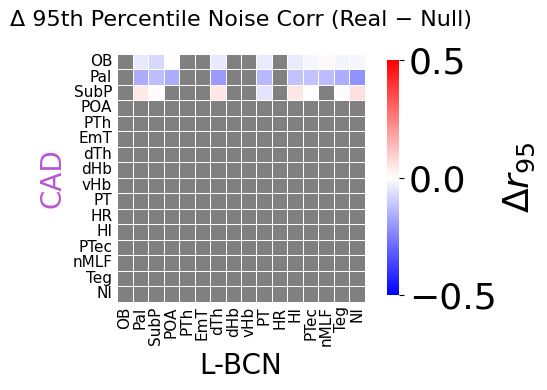

In [61]:
if summary_df is not None and len(summary_df) > 0:
    df = filter_by_min_pairs(summary_df.copy())
    df['diff_r95'] = df['real_r95'] - df['rand_mean_r95']

    if len(df) > 0:
        mat = build_heatmap_matrix(df, 'diff_r95', agg_fn='mean')
        masked = mat.mask(mat == 0)

        per_area_p = fisher_combine_pvalues(df, 'p_r95')   # one-sided greater
        sig_matrix = build_sig_matrix(masked, per_area_p)

        # ✅ Direction gate: for Δr95, only show stars when Δr95 > 0
        sig_matrix = sig_matrix & (masked > 0)

        fig, ax = plt.subplots(figsize=(6, 4))
        sns.heatmap(
            masked, vmin=-0.5, vmax=0.5, cmap='bwr', annot=False,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.95}, ax=ax
        )
        style_heatmap(ax, r'$\Delta r_{95}$')
        ax.set_title('Δ 95th Percentile Noise Corr (Real − Null)', fontsize=16, pad=20)
        add_significance_stars(ax, masked, sig_matrix)

        plt.tight_layout()
        save_figure('delta_r95_noise_corr')
        plt.show()
    else:
        print("⚠️  No area pairs after MIN_PAIRS_THRESHOLD filtering")
else:
    print("⚠️  summary_df is empty")

### 8.7 Δ 5th Percentile Correlation Heatmap

  ✓ Figure saved: delta_r5_noise_corr_CAD_vs_L-BCN_early_all_stim_all_bhv_all_areas_0.5.svg


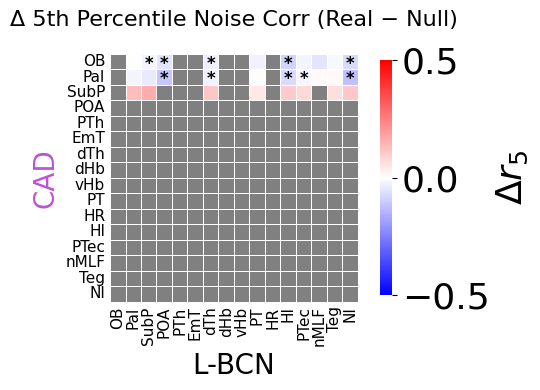

In [62]:
if summary_df is not None and len(summary_df) > 0:
    df = filter_by_min_pairs(summary_df.copy())
    df['diff_r5'] = df['real_r5'] - df['rand_mean_r5']

    if len(df) > 0:
        mat = build_heatmap_matrix(df, 'diff_r5', agg_fn='mean')
        masked = mat.mask(mat == 0)

        per_area_p = fisher_combine_pvalues(df, 'p_r5')
        sig_matrix = build_sig_matrix(masked, per_area_p)

        # ✅ Direction gate: for Δr5, only show stars when Δr5 < 0
        sig_matrix = sig_matrix & (masked < 0)

        fig, ax = plt.subplots(figsize=(6, 4))
        sns.heatmap(masked, vmin=-0.5, vmax=0.5, cmap='bwr', annot=False,
                    square=True, linewidths=0.5,
                    cbar_kws={'shrink': 0.95}, ax=ax)
        style_heatmap(ax, r'$\Delta r_{5}$')
        ax.set_title('Δ 5th Percentile Noise Corr (Real − Null)', fontsize=16, pad=20)
        add_significance_stars(ax, masked, sig_matrix)

        plt.tight_layout()
        save_figure('delta_r5_noise_corr')
        plt.show()
    else:
        print("⚠️  No area pairs after MIN_PAIRS_THRESHOLD filtering")
else:
    print("⚠️  summary_df is empty")

## 10. Results Summary

In [63]:
print("\n" + "=" * 80)
print("FINAL NOISE CORRELATION SUMMARY (WITH FDR)")
print("=" * 80)

if summary_df is None or len(summary_df) == 0:
    print("⚠️ summary_df is empty")
else:
    df = summary_df.copy()

    print(f"Fish analysed     : {df['fish_id'].nunique()}")
    print(f"Area pairs analysed: {df[['area1','area2']].drop_duplicates().shape[0]}")

    print("\nNeuron pair counts (n_pairs_real):")
    print(f"  Mean={df['n_pairs_real'].mean():.1f}  Min={df['n_pairs_real'].min()}  "
          f"Max={df['n_pairs_real'].max()}")

    print("\nGlobal averages (all fish × area pairs):")
    for label, rcol, ncol in [
        ('Mean corr', 'real_mean_r', 'rand_mean_mean'),
        ('95th pctl', 'real_r95',    'rand_mean_r95'),
        ('5th pctl',  'real_r5',     'rand_mean_r5'),
    ]:
        print(f"  {label}: real={df[rcol].mean():.4f}  null={df[ncol].mean():.4f}")

    df['diff_mean'] = df['real_mean_r'] - df['rand_mean_mean']
    df['diff_r95']  = df['real_r95']    - df['rand_mean_r95']
    df['diff_r5']   = df['real_r5']     - df['rand_mean_r5']

    print("\nMean differences (real − null):")
    for col, label in [('diff_mean','Mean'), ('diff_r95','r95'), ('diff_r5','r5')]:
        pct_pos = (df[col] > 0).mean() * 100
        print(f"  {label}: {df[col].mean():.4f}  (positive in {pct_pos:.1f}% of fish×pairs)")

    print("\nPer-fish significance (uncorrected):")
    for col, label in [('p_mean','Mean'), ('p_r95','r95'), ('p_r5','r5')]:
        print(f"  {label} p<0.05: {(df[col] < 0.05).mean()*100:.1f}%")

    # Area-pair level: Fisher + FDR
    area_rows = []
    for (a1, a2), g in df.groupby(['area1', 'area2'], sort=False):
        def fisher(pvals):
            return float(combine_pvalues(pvals, method='fisher')[1]) if len(pvals) else np.nan
        area_rows.append({
            'area1': a1, 'area2': a2,
            'n_fish': int(g['fish_id'].nunique()),
            'p_mean_fisher': fisher(g['p_mean'].dropna().values),
            'p_r95_fisher':  fisher(g['p_r95'].dropna().values),
            'p_r5_fisher':   fisher(g['p_r5'].dropna().values),
        })

    area_df = pd.DataFrame(area_rows)
    for col in ['p_mean_fisher', 'p_r95_fisher', 'p_r5_fisher']:
        qcol = col.replace('_fisher', '_fdr')
        area_df[qcol] = np.nan
        m = area_df[col].notna()
        if m.sum() > 0:
            _, q, _, _ = multipletests(area_df.loc[m, col], method='fdr_bh')
            area_df.loc[m, qcol] = q

    print("\nArea-pair significance (Fisher across fish, BH-FDR):")
    for metric in ['mean', 'r95', 'r5']:
        pcol, qcol = f'p_{metric}_fisher', f'p_{metric}_fdr'
        n_total = area_df[pcol].notna().sum()
        n_unc   = (area_df[pcol] < 0.05).sum()
        n_fdr   = (area_df[qcol] < FDR_ALPHA).sum()
        print(f"  {metric.upper():<4}  p<0.05: {n_unc}/{n_total}  |  FDR<{FDR_ALPHA}: {n_fdr}/{n_total}")

    print("\nTop 10 area pairs (by FDR, mean metric):")
    top = (area_df.sort_values('p_mean_fdr', na_position='last')
                  .head(10)[['area1', 'area2', 'n_fish', 'p_mean_fisher', 'p_mean_fdr']])
    print(top.to_string(index=False))

print("=" * 80)


FINAL NOISE CORRELATION SUMMARY (WITH FDR)
Fish analysed     : 4
Area pairs analysed: 45

Neuron pair counts (n_pairs_real):
  Mean=231.3  Min=4  Max=1232

Global averages (all fish × area pairs):
  Mean corr: real=-0.0029  null=0.0276
  95th pctl: real=0.2883  null=0.3427
  5th pctl: real=-0.2862  null=-0.2823

Mean differences (real − null):
  Mean: -0.0305  (positive in 38.2% of fish×pairs)
  r95: -0.0544  (positive in 32.6% of fish×pairs)
  r5: -0.0039  (positive in 43.8% of fish×pairs)

Per-fish significance (uncorrected):
  Mean p<0.05: 53.9%
  r95 p<0.05: 4.5%
  r5 p<0.05: 32.6%

Area-pair significance (Fisher across fish, BH-FDR):
  MEAN  p<0.05: 34/45  |  FDR<0.05: 31/45
  R95   p<0.05: 4/45  |  FDR<0.05: 1/45
  R5    p<0.05: 20/45  |  FDR<0.05: 12/45

Top 10 area pairs (by FDR, mean metric):
         area1                     area2  n_fish  p_mean_fisher  p_mean_fdr
       pallium            nucleus_isthmi       2       0.000054    0.000483
       pallium intermediate_hypoth

## 11. Export Results (Optional)

In [64]:
# Uncomment to save the per-fish area-pair summary table.
#
output_dir = Path('noise_corr_results')
output_dir.mkdir(exist_ok=True)
out_csv = output_dir / f'per_fish_area_pair_summary_{FILENAME_TAG}.csv'
summary_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

Saved: noise_corr_results/per_fish_area_pair_summary_CAD_vs_L-BCN_early_all_stim_all_bhv_all_areas_0.5.csv
